In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os 
import sys 

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [3]:
from classes.economy.order_book.utils.order_parser import PlannerParser

import networkx as nx 

from classes.economy.order_book.utils.price_looker import PriceLooker

from classes.economy.order_book.utils.order_completer import OrderCompleter

from classes.economy.production_process.production_process import ProductionGraph

from classes.economy.order_book.order.orders import BaseBuyOrder, BaseProductionOrder, BuyOrder, ProductionOrder

import matplotlib.pyplot as plt
import numpy as np


### Parser Demonstration

In [4]:
test_list = [(1, ('ZF', 'MKT'), 'Buy', 'RawMaterial'),
 (2, ('NCT', 'ZF'), 'Buy', 'RawMaterial'),
 (2, ('NCT',), 'Produce', 'Stage1'),
 (3, ('NCT',), 'Produce', 'Stage2'),
 (4, ('NCT',), 'Produce', 'FinalProduct'),
 (5, ('MKT', 'NCT'), 'Buy', 'FinalProduct')]

In [5]:
test_parser = PlannerParser()

test_parsed_orders = test_parser.parse_orders(test_list)

In [6]:
test_parsed_orders

[BaseBuyOrder(buyer='ZF', seller='MKT', good='RawMaterial', transaction_type='Buy'),
 BaseBuyOrder(buyer='NCT', seller='ZF', good='RawMaterial', transaction_type='Buy'),
 BaseProductionOrder(producer='NCT', produced_good='Stage1', transaction_type='Production'),
 BaseProductionOrder(producer='NCT', produced_good='Stage2', transaction_type='Production'),
 BaseProductionOrder(producer='NCT', produced_good='FinalProduct', transaction_type='Production'),
 BaseBuyOrder(buyer='MKT', seller='NCT', good='FinalProduct', transaction_type='Buy')]

### Price Lookup demonstration 

In [7]:
test_list =  [(1, ('ZF', 'MKT'), 'Buy', 'Input'),

(1, ('NCT', 'MKT'), 'Buy', 'Input'), 

(1, ('NCT', 'ZF'), 'Buy', 'Intermediate'),

(1, ('MKT', 'ZF'), 'Buy', 'Final')

]

In [8]:
test_parsed_list = test_parser.parse_orders(test_list)
test_parsed_list

[BaseBuyOrder(buyer='ZF', seller='MKT', good='Input', transaction_type='Buy'),
 BaseBuyOrder(buyer='NCT', seller='MKT', good='Input', transaction_type='Buy'),
 BaseBuyOrder(buyer='NCT', seller='ZF', good='Intermediate', transaction_type='Buy'),
 BaseBuyOrder(buyer='MKT', seller='ZF', good='Final', transaction_type='Buy')]

In [9]:
# Example Graph 

G = nx.DiGraph()
G.add_edges_from([
    ("Input", "Intermediate"),
    ("Intermediate", "Final"),
])



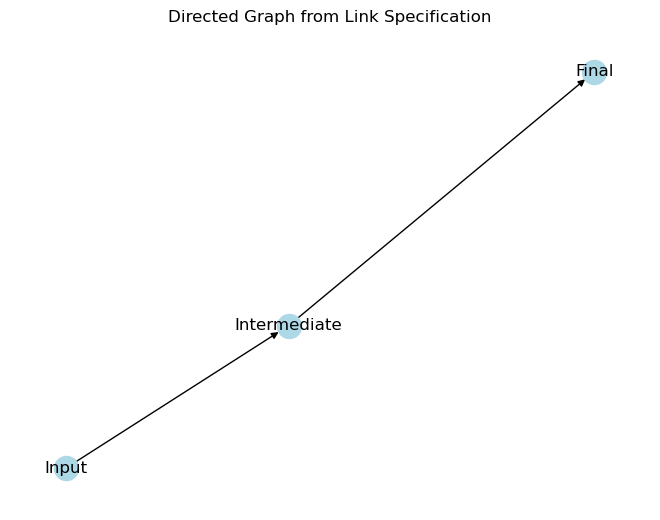

In [10]:
nx.draw(G , with_labels=True, node_color='lightblue', arrows=True)
plt.title("Directed Graph from Link Specification")
plt.show()

In [11]:
# Create production graph 

test_lookup_pgraph = ProductionGraph(G)

In [12]:
# Create agents mapping 
agents_mapping = { "MKT":0 , "NCT":1, "ZF":2 }

# Crear un tensor 3x3x3 con precios aleatorios entre 10 y 150
np.random.seed(42)
test_pmatrix = np.random.randint(low=10, high=151, size=(3, 3, 3))

print(test_pmatrix)

[[[112 102  24]
  [116  81  30]
  [112 131  84]]

 [[ 97 126 109]
  [113 140  62]
  [ 11  97  47]]

 [[139  30  67]
  [ 31  98  58]
  [ 68  24  60]]]


In [13]:
test_price_looker = PriceLooker(test_pmatrix, agents_mapping, test_lookup_pgraph)

In [14]:
test_order_completer = OrderCompleter(test_price_looker)

In [15]:
test_order1 = test_parsed_list[0]

test_order1

BaseBuyOrder(buyer='ZF', seller='MKT', good='Input', transaction_type='Buy')

In [16]:
test = test_order_completer.complete_order(test_order1)
test

BuyOrder(buyer='ZF', seller='MKT', good='Input', transaction_type='Buy', price=112)

In [18]:
for order in test_parsed_list:
    completed_order = test_order_completer.complete_order(order)
    print(completed_order)

BuyOrder(buyer='ZF', seller='MKT', good='Input', transaction_type='Buy', price=112)
BuyOrder(buyer='NCT', seller='MKT', good='Input', transaction_type='Buy', price=116)
BuyOrder(buyer='NCT', seller='ZF', good='Intermediate', transaction_type='Buy', price=62)
BuyOrder(buyer='MKT', seller='ZF', good='Final', transaction_type='Buy', price=67)
